# Trabajo Práctico N°3: Redes Neuronales

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import importlib
import numpy as np
import seaborn as sns
import time
import pandas as pd

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

preprocessing = importlib.import_module("src.preprocessing")
utils = importlib.import_module("src.utils")
models = importlib.import_module("src.models")
data_splitting = importlib.import_module("src.data_splitting")
metrics = importlib.import_module("src.metrics")
grid_search_ = importlib.import_module("src.grid_search")

importlib.reload(preprocessing)
importlib.reload(metrics)
importlib.reload(utils)
importlib.reload(models)
MLP = models.MLP
importlib.reload(data_splitting)


<module 'src.data_splitting' from 'c:\\Users\\aleja\\Documents\\ML\\TP3_ML\\Orozco_Alejandro_TP3\\src\\data_splitting.py'>

## 1. Análisis Y Preprocesamiento de Datos

In [2]:
X_images = np.load("../data/raw/X_images.npy")
y_images = np.load("../data/raw/y_images.npy")

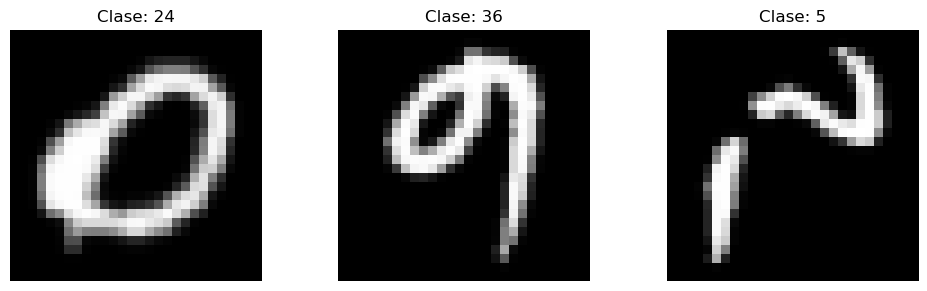

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in range(3):
    img = X_images[i].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Clase: {y_images[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
np.random.seed(42)
n_samples = X_images.shape[0]
indices = np.random.permutation(n_samples)

train_size = int(0.70 * n_samples)
val_size = int(0.15 * n_samples)

train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train, y_train = X_images[train_idx], y_images[train_idx]
X_val, y_val = X_images[val_idx], y_images[val_idx]
X_test, y_test = X_images[test_idx], y_images[test_idx]

print(f"Tamaño Train: {X_train.shape[0]} muestras")
print(f"Tamaño Validación: {X_val.shape[0]} muestras")
print(f"Tamaño Test: {X_test.shape[0]} muestras")

Tamaño Train: 566688 muestras
Tamaño Validación: 121433 muestras
Tamaño Test: 121434 muestras


In [5]:
# Normalizamos en float32 para reducir a la mitad el uso de memoria
X_train_norm = X_train.astype(np.float32) / np.float32(255.0)
X_val_norm = X_val.astype(np.float32) / np.float32(255.0)
X_test_norm = X_test.astype(np.float32) / np.float32(255.0)

# Liberamos los arrays crudos para evitar picos de memoria más adelante
del X_train, X_val, X_test

print(f"Rango de datos normalizados: Min={X_train_norm.min()}, Max={X_train_norm.max()}")

Rango de datos normalizados: Min=0.0, Max=1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

In [6]:
# Aplanamos las imágenes. La red MLP espera vectores 1D como entrada,
# por lo que pasamos de (N, 28, 28) a (N, 784)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)

# Entrada: 784 nodos (28x28)
# Capas ocultas: 128 y 64 nodos
# Salida: 47 nodos (clases de EMNIST)
arquitectura_M0 = [784, 128, 64, 47]

M0 = MLP(arquitectura_M0)

EPOCHS = 100
LEARNING_RATE = 0.1

print("Iniciando entrenamiento del modelo M0...")
train_loss, val_loss = M0.train(X_train_flat, y_train, X_val_flat, y_val, EPOCHS, LEARNING_RATE)

Iniciando entrenamiento del modelo M0...
Época 000 | Train Loss: 3.9174 | Val Loss: 3.7991
Época 010 | Train Loss: 3.3276 | Val Loss: 3.2836
Época 020 | Train Loss: 2.9367 | Val Loss: 2.8945
Época 030 | Train Loss: 2.5936 | Val Loss: 2.5538


KeyboardInterrupt: 

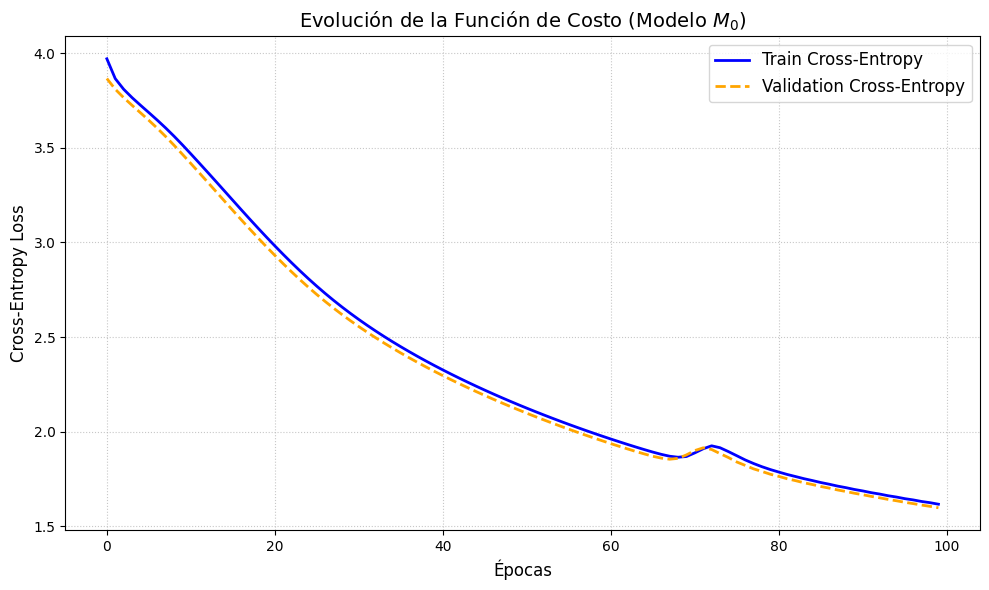

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Cross-Entropy', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Cross-Entropy', color='orange', linewidth=2, linestyle='--')

plt.title('Evolución de la Función de Costo (Modelo $M_0$)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:

num_classes = 47 # Clases en EMNIST

y_pred_train = metrics.predict(M0, X_train_flat)
y_pred_val = metrics.predict(M0, X_val_flat)

y_train_one_hot = models.to_one_hot(y_train, num_classes)
y_val_one_hot = models.to_one_hot(y_val, num_classes)

loss_train = M0.compute_loss(y_train_one_hot, M0.forward(X_train_flat))
loss_val = M0.compute_loss(y_val_one_hot, M0.forward(X_val_flat))

# --- Accuracy ---
acc_train = metrics.compute_accuracy(y_train, y_pred_train)
acc_val = metrics.compute_accuracy(y_val, y_pred_val)

# --- Matrices de Confusión ---
cm_train = metrics.compute_confusion_matrix(y_train, y_pred_train, num_classes)
cm_val = metrics.compute_confusion_matrix(y_val, y_pred_val, num_classes)

# --- F1-Score Macro ---
f1_train = metrics.compute_f1_macro(cm_train)
f1_val = metrics.compute_f1_macro(cm_val)

print("-" * 40)
print("REPORTE DE MÉTRICAS - MODELO M0")
print("-" * 40)
print("Métrica        | Train       | Validation")
print("---------------+-------------+-------------")
print(f"Cross-Entropy  | {loss_train:.4f}      | {loss_val:.4f}")
print(f"Accuracy       | {acc_train:.4f}      | {acc_val:.4f}")
print(f"F1-Score Macro | {f1_train:.4f}      | {f1_val:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE MÉTRICAS - MODELO M0
----------------------------------------
Métrica        | Train       | Validation
---------------+-------------+-------------
Cross-Entropy  | 1.6113      | 1.5986
Accuracy       | 0.5803      | 0.5832
F1-Score Macro | 0.3481      | 0.3493
----------------------------------------


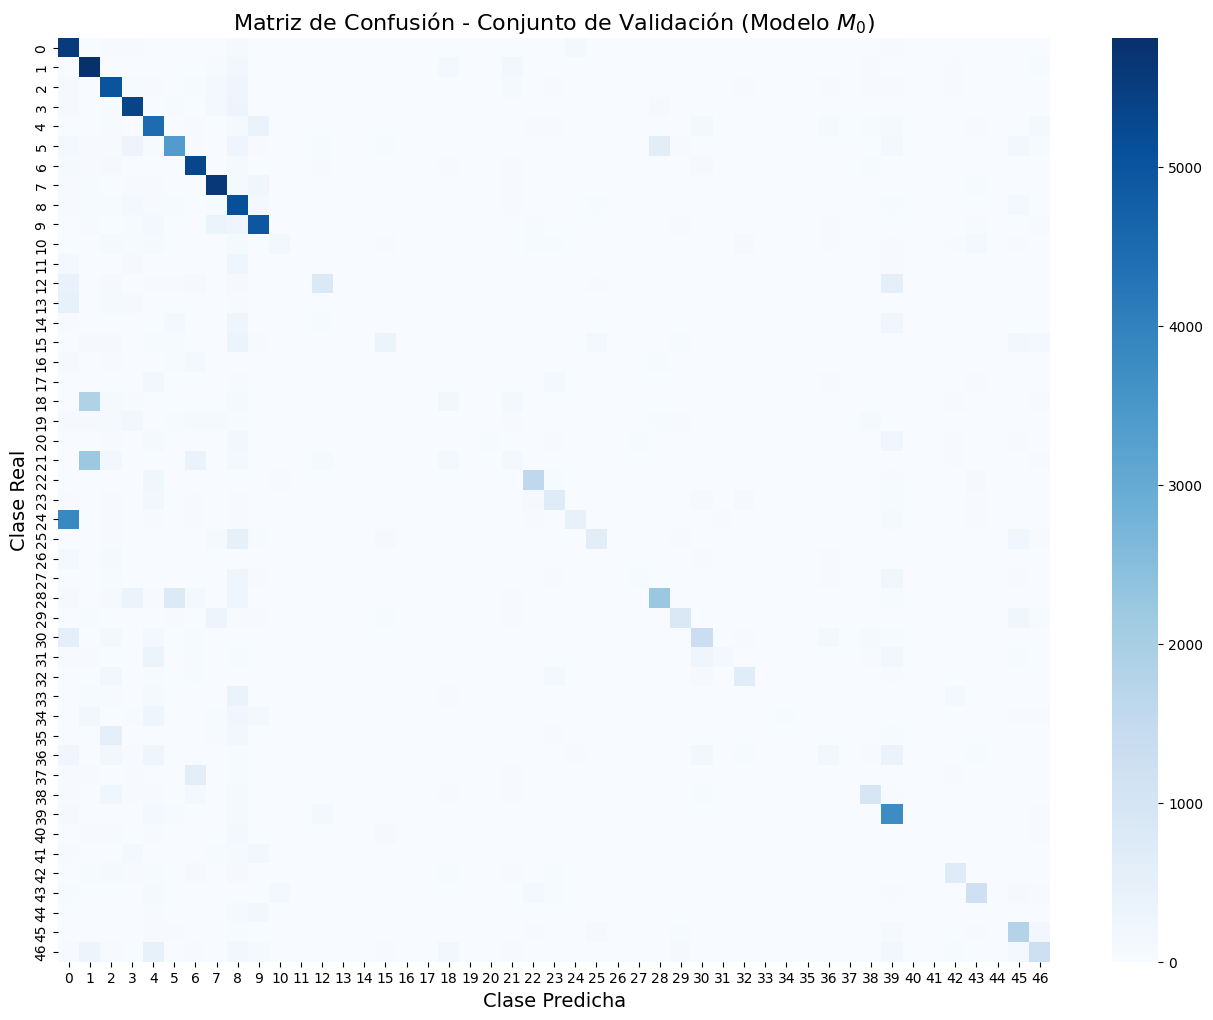

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(cm_val, annot=False, cmap='Blues', fmt='g', cbar=True)

plt.title('Matriz de Confusión - Conjunto de Validación (Modelo $M_0$)', fontsize=16)
plt.xlabel('Clase Predicha', fontsize=14)
plt.ylabel('Clase Real', fontsize=14)
plt.show()

## Punto 3: Grid Search - Búsqueda Exhaustiva de Mejores Hiperparámetros (M1)

In [ ]:
M1_config, historial_grid, df_top5 = grid_search_.grid_search(
    X_train_flat, y_train, X_val_flat, y_val,
    epochs=40,
    patience=5
)

In [ ]:
# --- DEFINIR VARIABLES DE M0 BASELINE (del punto 8) ---
# Reutilizamos los resultados de M0 entrenado anteriormente
train_loss_m0 = train_loss 
val_loss_m0 = val_loss      

# --- ENTRENAR M1 CON MEJOR CONFIGURACIÓN (100 épocas completas) ---
print("\n" + "="*100)
print("ENTRENANDO M1 CON MEJOR CONFIGURACIÓN (100 ÉPOCAS)")
print("="*100)

M1 = models.MLP_Advanced(M1_config['arquitectura'])

print("\nConfiguración M1:")
print(f"  • Arquitectura: {M1_config['arquitectura']}")
print(f"  • Optimizer: {M1_config['optimizer']}")
print(f"  • Learning Rate: {M1_config['learning_rate']}")
print(f"  • Batch Size: {M1_config['batch_size']}")
print(f"  • L2 Regularización: {M1_config['l2']}")
print("\n")

t_start = time.time()
train_loss_m1, val_loss_m1 = M1.train(
    X_train_flat, y_train, X_val_flat, y_val,
    epochs=100,
    learning_rate=M1_config['learning_rate'],
    batch_size=M1_config['batch_size'],
    optimizer=M1_config['optimizer'],
    l2=M1_config['l2'],
    patience=10,
    scheduler_type='exponential',
    decay_rate=0.05,
    final_lr=1e-5
)
t_m1 = time.time() - t_start

print(f"\n✓ M1 entrenado en {t_m1:.1f} segundos")
print(f"  • Loss Train Final: {train_loss_m1[-1]:.4f}")
print(f"  • Loss Val Final: {val_loss_m1[-1]:.4f}")
print(f"  • Mejora vs M0: {((val_loss_m1[-1] - val_loss_m0[-1]) / val_loss_m0[-1]) * 100:+.2f}%")


In [ ]:
# --- COMPARACIÓN M0 vs M1 ---
print("\n" + "="*100)
print("COMPARACIÓN: M0 BASE vs M1 OPTIMIZADO")
print("="*100 + "\n")

# Tabla comparativa
comparacion_data = {
    'Modelo': ['M0 BASE', 'M1 OPTIMIZADO'],
    'Arquitectura': [
        str([784, 128, 64, 47]),
        str(M1_config['arquitectura'])
    ],
    'Optimizer': ['SGD', M1_config['optimizer']],
    'Learning Rate': [0.1, M1_config['learning_rate']],
    'Batch Size': ['Full', M1_config['batch_size']],
    'L2': [0.0, M1_config['l2']],
    'Train Loss': [f"{train_loss_m0[-1]:.4f}", f"{train_loss_m1[-1]:.4f}"],
    'Val Loss': [f"{val_loss_m0[-1]:.4f}", f"{val_loss_m1[-1]:.4f}"],
    'Δ Val Loss': ['—', f"{((val_loss_m1[-1] - val_loss_m0[-1]) / val_loss_m0[-1]) * 100:+.2f}%"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print(df_comparacion.to_string(index=False))

# Gráfico de convergencia comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curvas de ambos modelos
ax1.plot(train_loss_m0, label='M0 Train', linewidth=2, color='blue', alpha=0.7)
ax1.plot(val_loss_m0, label='M0 Val', linewidth=2, color='blue', linestyle='--', alpha=0.7)
ax1.plot(train_loss_m1, label='M1 Train', linewidth=2, color='green', alpha=0.7)
ax1.plot(val_loss_m1, label='M1 Val', linewidth=2, color='green', linestyle='--', alpha=0.7)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Convergencia: M0 vs M1', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Validación Loss solo (zoom in)
ax2.plot(val_loss_m0, label='M0 Val Loss', linewidth=2.5, color='blue', marker='o', markersize=4, alpha=0.7)
ax2.plot(val_loss_m1, label='M1 Val Loss', linewidth=2.5, color='green', marker='s', markersize=4, alpha=0.7)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Validation Loss', fontsize=11)
ax2.set_title('Validación Loss: M0 vs M1 (Comparación Directa)', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Comparación completada.")
